# Predictive Maintenance: Machine Failure Prediction

**Objective**
To build a Machine Learning model that predicts equipment failure from sensor data (Temperature, Torque, and Wear), transforming reactive repairs into predictive maintenance.

**Key Challenges**
1. Imbalanced Data: Failures represent only 3% of the dataset, making "Accuracy" a misleading metric.
2. Goal: Maximize Recall (catching every failure) while maintaining high Precision (avoiding false alarms).

**Approach**
Train a Logistic Regression model as a simple benchmark and then move training to a non linear Random Forest classifier to capture complex patterns.

**Evaluation**
 Compare performance using Confusion Matrices and Classification Reports.

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mlt
import matplotlib.pyplot as plt

In [13]:
# Splitting data for model training 
from sklearn.model_selection import train_test_split

cleaned_data = pd.read_csv("../data/cleaned_data.csv")
print(cleaned_data.columns.to_list())
X = cleaned_data.drop(columns="Machine failure")
y = cleaned_data["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify= y, random_state=42)
# print(X_train.shape)
# print(y_train.shape)
# print(X_test.shape)
# print(y_test.shape)

['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure']


Accuracy: 96.85%


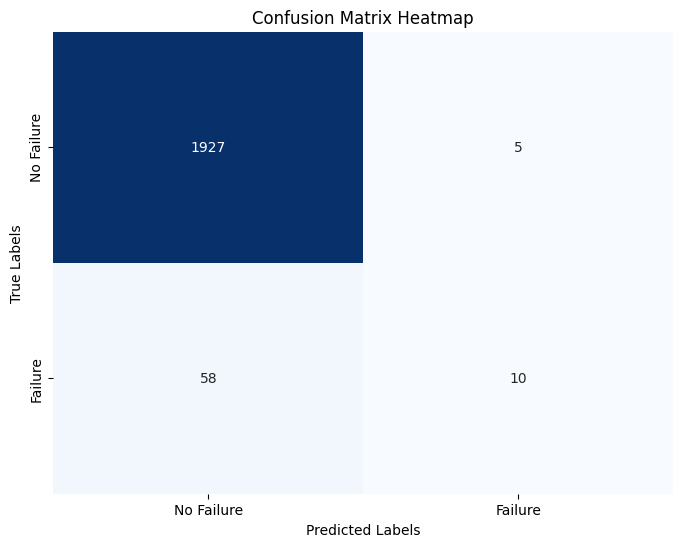

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.67      0.15      0.24        68

    accuracy                           0.97      2000
   macro avg       0.82      0.57      0.61      2000
weighted avg       0.96      0.97      0.96      2000



In [14]:
# Model Training using Logistic Regression - a linear approach

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lrreg_model = LogisticRegression(max_iter=1000)
lrreg_model.fit(X_train,y_train)
yreg_pred = lrreg_model.predict(X_test)

accuracy = accuracy_score(y_test, yreg_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, yreg_pred)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
           xticklabels=['No Failure', 'Failure'], 
            yticklabels=['No Failure', 'Failure'])

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_test,yreg_pred))



Accuracy: 98.40%


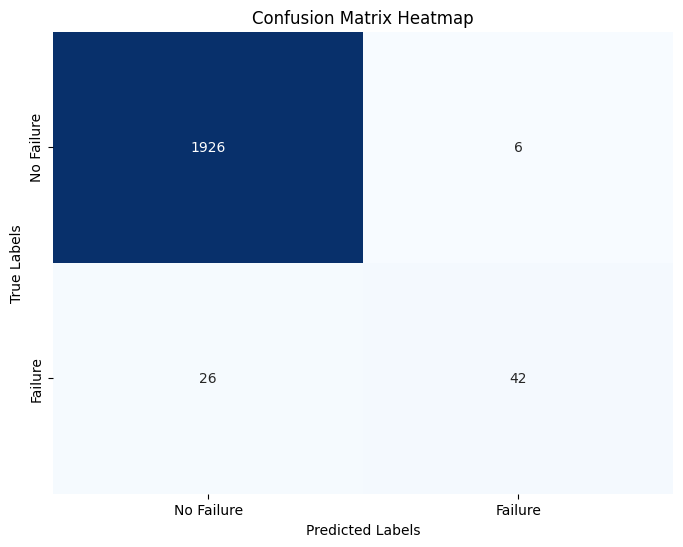

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.62      0.72        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [15]:
# Model Training for Random forest - a Non linear approach
from sklearn.ensemble import RandomForestClassifier


random_classifier = RandomForestClassifier(n_estimators=1000, random_state=42)
random_classifier.fit(X_train,y_train)
yrandom_pred = random_classifier.predict(X_test)

accuracy = accuracy_score(y_test, yrandom_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, yrandom_pred)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
           xticklabels=['No Failure', 'Failure'], 
            yticklabels=['No Failure', 'Failure'])

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Show Precision, Recall, and F1-Score
print(classification_report(y_test, yrandom_pred))

C:\Users\urooj\AppData\Local\Temp\ipykernel_25248\1853970746.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


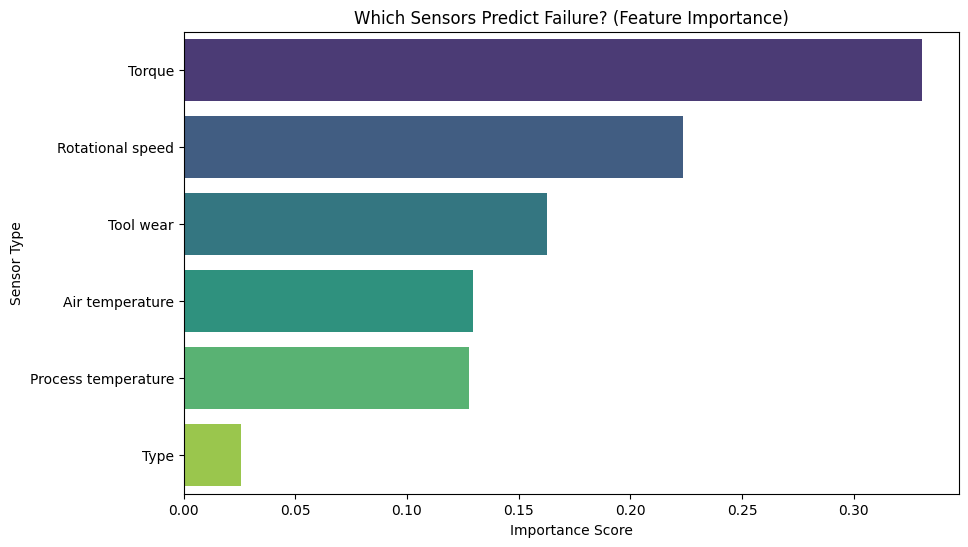

In [16]:
# 1. Get feature importance from your Random Forest model
importances = random_classifier.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Which Sensors Predict Failure? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Sensor Type')
plt.show()

['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
Accuracy: 98.40%


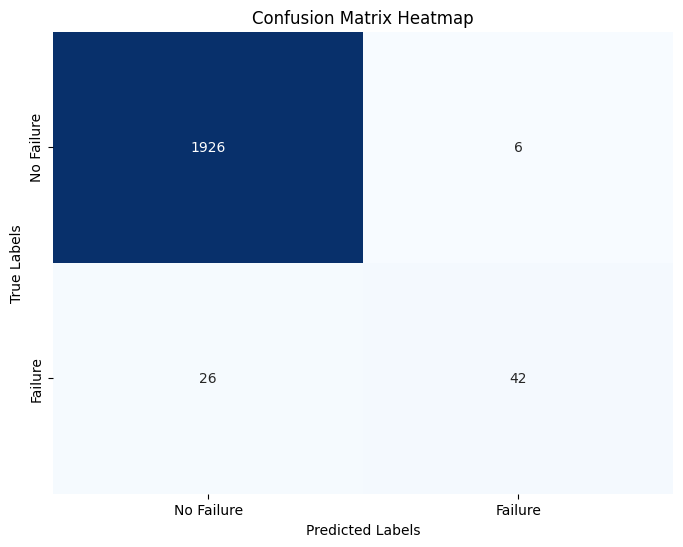

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.94      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000



In [17]:
# Model training using gradient boosting

from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(random_state=42, learning_rate=0.1, max_depth= 3 , n_estimators=100)
gbc_model.fit(X_train, y_train)
print(X_train.columns.to_list())
gbc_predict = gbc_model.predict(X_test)

accuracy = accuracy_score(y_test, yrandom_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, yrandom_pred)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
           xticklabels=['No Failure', 'Failure'], 
            yticklabels=['No Failure', 'Failure'])

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Show Precision, Recall, and F1-Score
gbc_report = classification_report(y_test,gbc_predict)
print(gbc_report)


## Model Evaluation and Final Selection

Both Random Forest and Gradient Boosting achieved similar overall accuracy.

However, a deeper analysis of class-wise performance shows that Gradient Boosting provides higher precision, recall, and F1-score for the failure class (class 1).

In predictive maintenance systems, detecting failures is critical. Missing a failure (false negative) can lead to unexpected downtime and high operational costs.

Therefore, recall for the failure class is prioritized over overall accuracy.

### Final Decision

Gradient Boosting is selected as the final model because it improves detection of failure events, making it more suitable for real-world industrial deployment.

### Trade-off

This comes with a slight trade-off in precision, meaning more false alarms may occur. However, in industrial settings, this is acceptable compared to the risk of missed failures.

In [18]:
import joblib

joblib.dump(gbc_model, "../model/predictive_maintenance_model.plk")

['../model/predictive_maintenance_model.plk']